# Forcasting Harmonic Osscilators using a Physics Informed Neural Network in Pytorch


**Loading in librarys**

In [93]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Oscillators import *


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Generating training and testing data



In [94]:
m = 1.0
k = 1.0
A_0 = 1.0
v_0 = 0.0
b = 0.01
F_0 = 1
w_0 = 0.8


oscillator = Harmonic_Oscillator(
    mass=m,
    force_const=k,          # → ω₀ = √(k/m) = 1.0
    initial_amplitude=A_0,    # Start with same amplitude as driven oscillation
    velocity=v_0,             # Zero initial velocity for clean phase
    damping_const=b,       # Very light damping (γ = b/2m = 0.005)
    driving_force=F_0,
    driving_frequency=w_0    # Close to ω₀ = 1.0 → beat frequency ≈ 0.05
)

points = 1000
t = np.linspace(0, 100, 1000)
x = oscillator.get_x_pos(t)

# plain floats, not np.float64, so they stay weakly typed against float32 tensors
t_mean, t_std = float(t.mean()), float(t.std())
t_norm = (t-t_mean) / t_std

x_mean, x_std = float(x.mean()), float(x.std())
x_norm = (x-x_mean) / x_std

# Obtaining random training values, and letting the rests of the values be testing values

training_values = 100

np.random.seed(42)

# without replacement and over the full index range - randint(0, points - 1) both
# duplicated indices and could never pick the final point, which left the right
# hand edge as pure extrapolation
training_index = np.random.choice(points, training_values, replace=False)
#print(training_index)

test_data_index = np.setdiff1d(np.arange(points), training_index)

training_data_t, training_data_x, test_data_t, test_data_x = [], [], [], []

for i in training_index:
    training_data_t.append(t_norm[i])
    training_data_x.append(x_norm[i])
#training_data = torch.tensor(training_data_list)


for i in test_data_index:
    test_data_t.append(t_norm[i])
    test_data_x.append(x_norm[i]) 


In [95]:
batch_size = 100

# Turned into a tensor to create data to be used in nn
training_data_t = torch.tensor(training_data_t, dtype = torch.float32).reshape(-1, 1)
training_data_x = torch.tensor(training_data_x, dtype = torch.float32).reshape(-1, 1)

test_data_t = torch.tensor(test_data_t, dtype = torch.float32).reshape(-1, 1)
test_data_x = torch.tensor(test_data_x, dtype = torch.float32).reshape(-1, 1)



training_dataset = TensorDataset(training_data_t, training_data_x)
test_dataset = TensorDataset(test_data_t, test_data_x)

training_dataloader = DataLoader(training_dataset, shuffle=True,  batch_size = batch_size)
# one batch, unshuffled - so the plotting cell gets the test points back in time order
test_dataloader = DataLoader(test_dataset, batch_size = len(test_dataset))
for X, y in training_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Shape of X: torch.Size([100, 1])
Shape of y: torch.Size([100, 1]) torch.float32


## Defining a model 

In [96]:
# Define model
hidden_neurons = 64

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_relu_stack = nn.Sequential(
            
            nn.Linear(1, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, 1)
        )

    def forward(self, t):

        logits = self.linear_relu_stack(t)
        return logits

#model = NeuralNetwork().to(device)
#print(model)

### Loss function


In [97]:

n_colloc = 200
physics_const = 1 
basic_const = 1


def ode_residual(t_colloc, x_colloc):
    """Dimensionless residual of  m * d2x/dt2 + b * dx/dt + k * x - F_0 cos(w_0 t),
    given the network's normalised output x_colloc = x_norm(t_norm).

    Pulled out of CustomLoss so the training loss and the evaluation report share
    one definition of the physics instead of two that can drift apart.
    """
    dxdt_norm = torch.autograd.grad(x_colloc, t_colloc, 
                               grad_outputs=torch.ones_like(x_colloc), # means doenst calculate arbritaty calculations between x_i and t_j
                               create_graph=True)[0]

    d2xdt2_norm = torch.autograd.grad(dxdt_norm, t_colloc, 
                               grad_outputs=torch.ones_like(dxdt_norm),
                               create_graph=True)[0]

    # the network outputs x_norm as a function of t_norm, so undo BOTH
    # normalisations before the derivatives mean anything physically:
    #   x = x_norm * x_std + x_mean,  t = t_norm * t_std + t_mean
    # dx/dt    = dx_norm/dt_norm * x_std / t_std
    # d2x/dt2  = d2x_norm/dt_norm2 * x_std / t_std ** 2
    dxdt = dxdt_norm * x_std / t_std
    d2xdt2 = d2xdt2_norm * x_std / t_std ** 2

    x_phys = x_colloc * x_std + x_mean
    t_phys = t_colloc * t_std + t_mean

    # divided by F_0 so the residual is dimensionless and physics_const is O(1)
    return (m * d2xdt2 + b * dxdt + k * x_phys - F_0 * torch.cos(w_0 * t_phys)) / F_0


class CustomLoss(nn.Module):
    def __init__(self):
        super(CustomLoss, self).__init__()

    def forward(self, output, target, t_colloc, x_colloc):

        basic_loss = nn.functional.mse_loss(output, target)

        # also need it to fit to osccilator equation
        # can use any arbritary t, as we are not labling them with correct solution
        residual = ode_residual(t_colloc, x_colloc)
        colloc_loss = nn.functional.mse_loss(residual, torch.zeros_like(residual))

        return basic_const * basic_loss + physics_const * colloc_loss





## Training

In [98]:
t_lo, t_hi = float(t_norm.min()), float(t_norm.max())


def make_colloc(n):
    """Fresh collocation points, resampled each call so the physics term isn't
    only enforced on one fixed grid. Built directly on `device` and made a leaf
    there, so autograd.grad still works on CUDA."""
    return (torch.rand(n, 1, device=device) * (t_hi - t_lo) + t_lo).requires_grad_(True)


def run_training(use_physics, epochs=10000, lr=1e-3, use_scheduler=True,
                 seed=0, log_every=500):
    """Train a fresh network and return it. use_physics picks the loss:
    False -> plain MSE on the data, True -> CustomLoss (data + ODE residual)."""
    torch.manual_seed(seed)                 # identical init for both runs, so any
    model = NeuralNetwork().to(device)      # difference is down to the physics term
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # built here rather than at module scope, so re-running this cell always
    # starts a new anneal instead of inheriting an lr the last run left at 0
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
                 if use_scheduler else None)
    loss_fn = CustomLoss() if use_physics else nn.MSELoss()

    history = []
    for epoch in range(epochs):
        model.train()
        for T, X in training_dataloader:
            T, X = T.to(device), X.to(device)

            pred = model(T)
            if use_physics:
                t_colloc = make_colloc(n_colloc)
                loss = loss_fn(pred, X, t_colloc, model(t_colloc))
            else:
                loss = loss_fn(pred, X)

            # Backpropagation
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        if scheduler is not None:
            scheduler.step()

        history.append(loss.item())
        if epoch % log_every == 0 or epoch == epochs - 1:
            print(f"epoch {epoch+1:>6}/{epochs}  loss {loss.item():.6f}"
                  f"  lr {optimizer.param_groups[0]['lr']:.2e}")

    return model, history


def evaluate(model, dataloader, label=""):
    """Data MSE and physics residual reported SEPARATELY, so the basic and PINN
    runs are measured on the same scale whichever loss trained them. The combined
    training objective is not comparable between the two."""
    model.eval()

    sq, n = 0.0, 0
    with torch.no_grad():                   # the data term needs no graph...
        for T, X in dataloader:
            T, X = T.to(device), X.to(device)
            sq += nn.functional.mse_loss(model(T), X, reduction="sum").item()
            n += X.numel()
    data_mse = sq / n

    t_colloc = make_colloc(n_colloc)        # ...but the residual does
    physics_mse = ode_residual(t_colloc, model(t_colloc)).pow(2).mean().item()

    print(f"{label}  test data MSE {data_mse:.6f}"
          f"  | RMSE {np.sqrt(data_mse) * x_std:.4f} (units of x)"
          f"  | physics residual MSE {physics_mse:.6f}")
    return {"data_mse": data_mse, "physics_mse": physics_mse}


### Training the basic network

Data only — plain MSE against the 100 sampled points. Nothing constrains what the
network does *between* those points.

In [99]:
model_basic, hist_basic = run_training(use_physics=False, epochs=10000, lr=1e-3)
res_basic = evaluate(model_basic, test_dataloader, label="basic")


epoch      1/10000  loss 1.100425  lr 1.00e-03
epoch    501/10000  loss 0.917786  lr 9.94e-04
epoch   1001/10000  loss 0.767863  lr 9.75e-04
epoch   1501/10000  loss 0.615185  lr 9.45e-04
epoch   2001/10000  loss 0.366488  lr 9.04e-04
epoch   2501/10000  loss 0.213142  lr 8.53e-04
epoch   3001/10000  loss 0.103869  lr 7.94e-04
epoch   3501/10000  loss 0.024904  lr 7.27e-04
epoch   4001/10000  loss 0.004319  lr 6.54e-04
epoch   4501/10000  loss 0.001061  lr 5.78e-04
epoch   5001/10000  loss 0.000566  lr 5.00e-04
epoch   5501/10000  loss 0.000414  lr 4.22e-04
epoch   6001/10000  loss 0.000333  lr 3.45e-04
epoch   6501/10000  loss 0.000274  lr 2.73e-04
epoch   7001/10000  loss 0.000231  lr 2.06e-04
epoch   7501/10000  loss 0.000200  lr 1.46e-04
epoch   8001/10000  loss 0.000177  lr 9.54e-05
epoch   8501/10000  loss 0.000162  lr 5.44e-05
epoch   9001/10000  loss 0.000154  lr 2.44e-05
epoch   9501/10000  loss 0.000150  lr 6.13e-06
epoch  10000/10000  loss 0.000149  lr 0.00e+00
basic  test d

### Training the PINN

Same data loss (weighted by `basic_const`) plus the ODE residual evaluated at
`n_colloc` unlabelled collocation points, which is what constrains the gaps.

In [100]:
model_pinn, hist_pinn = run_training(use_physics=True, epochs=10000, lr=1e-3)
res_pinn = evaluate(model_pinn, test_dataloader, label="PINN ")


epoch      1/10000  loss 1.903508  lr 1.00e-03
epoch    501/10000  loss 1.614443  lr 9.94e-04
epoch   1001/10000  loss 1.634120  lr 9.75e-04
epoch   1501/10000  loss 1.582196  lr 9.45e-04
epoch   2001/10000  loss 1.606608  lr 9.04e-04
epoch   2501/10000  loss 1.612025  lr 8.53e-04
epoch   3001/10000  loss 1.624156  lr 7.94e-04
epoch   3501/10000  loss 1.623522  lr 7.27e-04
epoch   4001/10000  loss 1.573229  lr 6.54e-04
epoch   4501/10000  loss 1.599138  lr 5.78e-04
epoch   5001/10000  loss 1.628446  lr 5.00e-04


KeyboardInterrupt: 

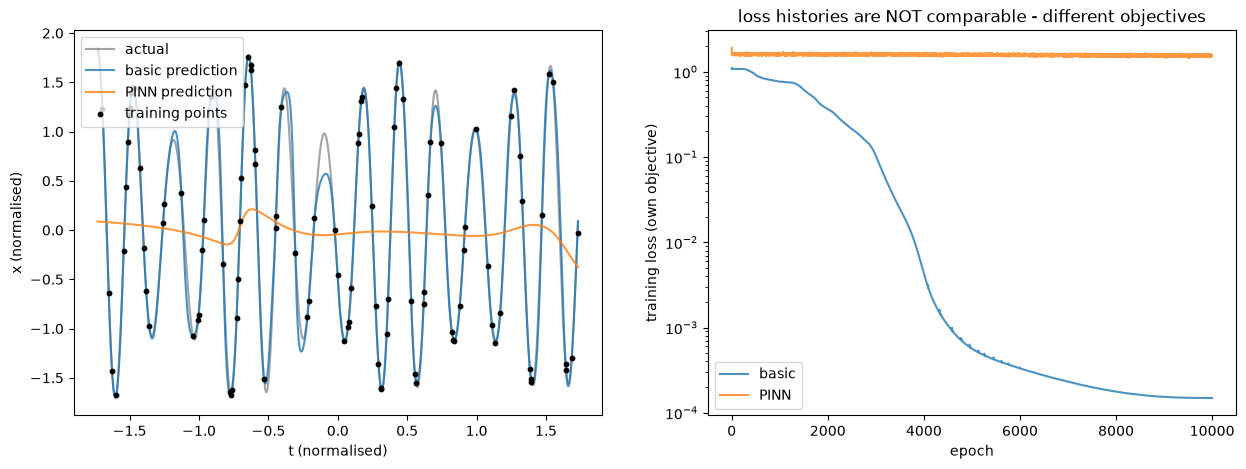

In [ ]:
### Plotting Results
t_grid = torch.tensor(t_norm, dtype=torch.float32).reshape(-1, 1).to(device)

# whichever training cells have been run
trained = {}
if "model_basic" in globals():
    trained["basic"] = (model_basic, hist_basic)
if "model_pinn" in globals():
    trained["PINN"] = (model_pinn, hist_pinn)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax.plot(t_norm, x_norm, label="actual", color="0.4", alpha=0.6)
for name, (mdl, _) in trained.items():
    mdl.eval()
    with torch.no_grad():
        pred = mdl(t_grid).cpu().squeeze()
    ax.plot(t_norm, pred, label=f"{name} prediction", alpha=0.8)

# the training points - gaps between them are where the fit is free to wander
ax.scatter(t_norm[training_index], x_norm[training_index],
           s=10, color="k", zorder=3, label="training points")
ax.set_xlabel("t (normalised)")
ax.set_ylabel("x (normalised)")
ax.legend()

for name, (_, hist) in trained.items():
    ax2.plot(hist, label=name, alpha=0.8)
ax2.set_yscale("log")
ax2.set_xlabel("epoch")
ax2.set_ylabel("training loss (own objective)")
ax2.set_title("loss histories are NOT comparable - different objectives")
ax2.legend()
